In [243]:
# Auto-reload modules to ensure we use the latest code
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd

# Add parent directory to path to import from src/ - DO THIS FIRST
# Get the notebook's directory, then go up one level to project root
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
project_root = os.path.dirname(notebook_dir)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Project root: {project_root}")

# Now import everything - path is set up
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.optim import Adam

# Import PINN models from external module
from src.pinn_models import PressureHeadNet, WaterTableNet, RichardsPINN
# Import normalization helper from external module
from src.normalization_helper import NormalizationHelper
# Import sampling helpers and loss computation functions from external module
from src.training_utils import (
    SamplingHelpers, 
    compute_losses, 
    apply_weights_and_compute_gradients, 
    apply_weights_fixed_mode
)
# Import WeightManager from external module
from src.training_utils import WeightManager
# Import CachePoolManager from external module
from src.training_utils import CachePoolManager
# Import gradient computation utilities from external module
from src.training_utils import compute_grad_norm, compute_total_grad_norm
# Import TrainingLogger from external module
from src.training_logger import TrainingLogger
#training function
from src.train_loop import train_pinn_pool_batch_autoweight
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set random seed
torch.manual_seed(44)
np.random.seed(44)

print("✓ Modules loaded with autoreload enabled")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root: /Users/jasonjing/Documents/smap/SMAP-Recharge-Flux
Using device: cpu
✓ Modules loaded with autoreload enabled


LOADING CALHOUN SOIL MOISTURE DATA

Data loaded:
  Total records: 17521
  Time range: 2017-01-01 01:00:00 to 2018-01-01 00:00:00
  Duration: ~364 days
  Resolution: 30 minutes

REPLACING MISSING VALUE CODES (-9999) WITH NaN
Missing value codes replaced with NaN

Time period selection (date-based):
  Start date: 2017-05-19 00:00:00
  End date:   2017-05-26 00:00:00
  Selected:   337 points
  Date range: 2017-05-19 00:00:00 to 2017-05-26 00:00:00
  Duration:   7.0 days

Raw data quality (after replacing -9999 with NaN):
----------------------------------------------------------------------
2cm   :   337 valid,     0 NaN ( 0.00%), range=[0.0652, 0.3694]
15cm  :   337 valid,     0 NaN ( 0.00%), range=[0.1249, 0.3872]
30cm  :   337 valid,     0 NaN ( 0.00%), range=[0.1230, 0.3964]
40cm  :   337 valid,     0 NaN ( 0.00%), range=[0.1601, 0.4024]
60cm  :   337 valid,     0 NaN ( 0.00%), range=[0.1818, 0.3704]
80cm  :   337 valid,     0 NaN ( 0.00%), range=[0.2718, 0.4827]

DATA CLEANING: INTER

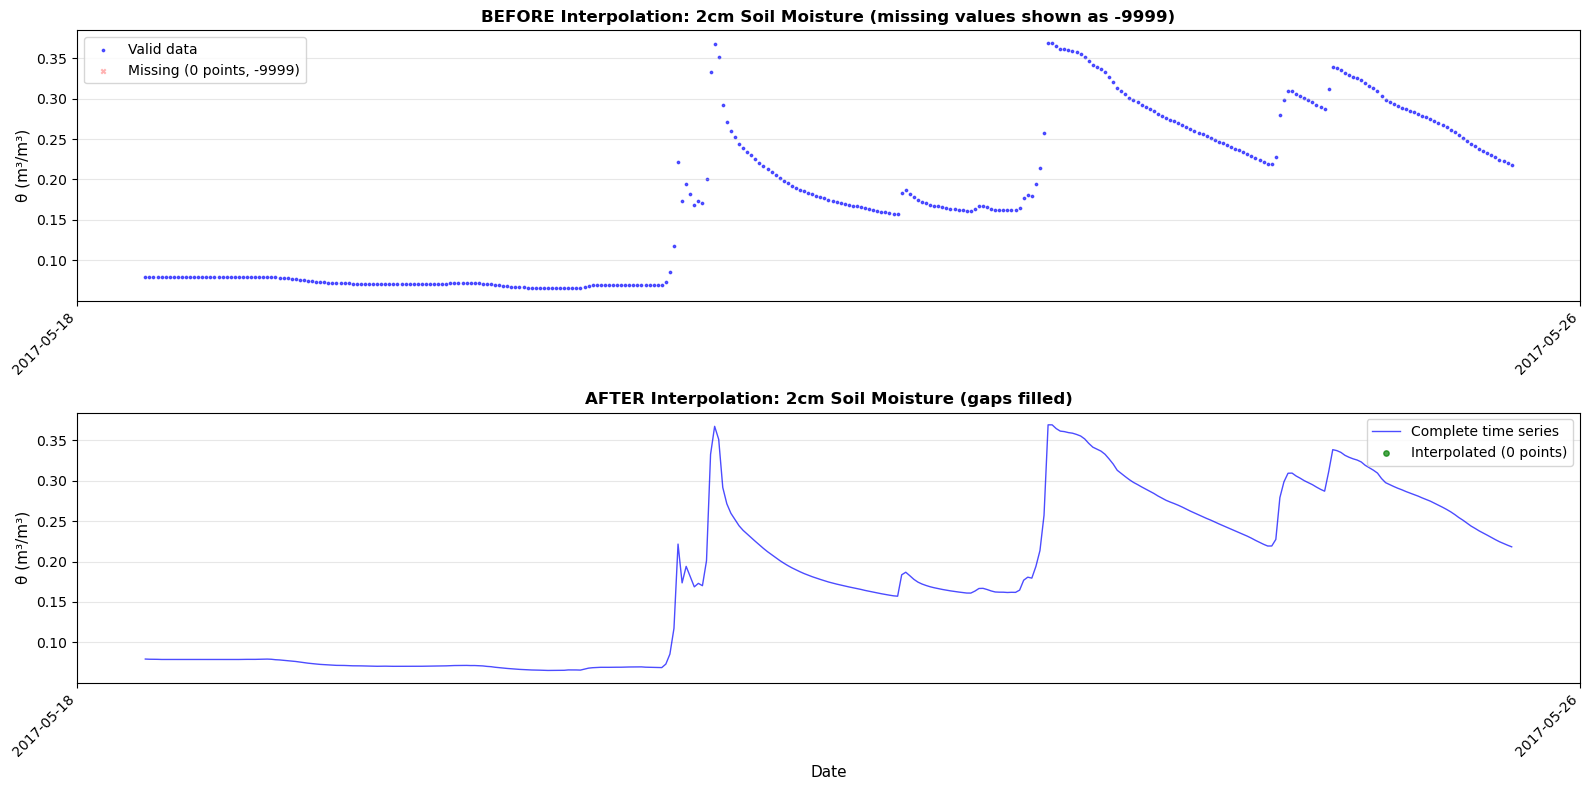


Interpolation Summary for Surface (2cm):
  Original valid points: 337
  Missing values (-9999): 0
  Points interpolated:   0
  Final valid points:    337
  Data completeness:     100.0%

DATA LOADING AND CLEANING COMPLETE


In [244]:
# ============================================================================
# LOAD SOIL MOISTURE DATA FROM CALHOUN EXPERIMENTAL FOREST
# ============================================================================

from src.data_loader import load_calhoun_soil_moisture
import matplotlib.dates as mdates

# ============================================================================
# TIME PERIOD SELECTION - Choose one option:
# ============================================================================

# OPTION 1: Load ALL data (default)
soil_data = load_calhoun_soil_moisture(
    filepath='../data/2017_HalfHourly_UTC_ForestSite1.xlsx',
    interpolate=True,
    max_gap_hours=6,
    start_date='2017-05-19',  # March 1, 2017
    end_date='2017-05-26',    # May 31, 2017
    verbose=True
)



# Extract cleaned data for easy access
datetime_col = soil_data['datetime']
times_seconds = soil_data['times_seconds']
theta_2cm = soil_data['theta_2cm']
theta_2cm=theta_2cm
theta_15cm = soil_data['theta_15cm']
theta_30cm = soil_data['theta_30cm']
theta_40cm = soil_data['theta_40cm']
theta_60cm = soil_data['theta_60cm']
theta_80cm = soil_data['theta_80cm']
depths_names = soil_data['depths_names']

# ============================================================================
# VISUALIZE INTERPOLATION QUALITY (SURFACE LAYER)
# ============================================================================

print("\n" + "="*70)
print("VISUALIZING INTERPOLATION QUALITY (2cm surface layer)")
print("="*70)

# Get raw data for comparison
theta_2cm_raw = soil_data['raw_data'][0]

# Focus on surface layer (2cm) - most important for BC
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Plot 1: Before interpolation
ax1 = axes[0]
valid_mask = ~pd.isna(theta_2cm_raw)
ax1.scatter(datetime_col[valid_mask], theta_2cm_raw[valid_mask], 
           s=3, alpha=0.6, color='blue', label='Valid data')
ax1.scatter(datetime_col[~valid_mask], np.full((~valid_mask).sum(), np.nanmean(theta_2cm_raw)),
           s=10, alpha=0.3, color='red', marker='x', label=f'Missing ({(~valid_mask).sum()} points, -9999)')
ax1.set_ylabel('θ (m³/m³)', fontsize=11)
ax1.set_title('BEFORE Interpolation: 2cm Soil Moisture (missing values shown as -9999)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Plot 2: After interpolation
ax2 = axes[1]
still_nan_mask = pd.isna(theta_2cm)
filled_mask = pd.isna(theta_2cm_raw) & ~pd.isna(theta_2cm)
n_filled_2cm = soil_data['interpolation_stats']['2cm']['n_filled']

ax2.plot(datetime_col, theta_2cm, linewidth=1, alpha=0.7, color='blue', label='Complete time series')
ax2.scatter(datetime_col[filled_mask], theta_2cm[filled_mask],
           s=15, alpha=0.7, color='green', marker='o', label=f'Interpolated ({n_filled_2cm} points)', zorder=5)
if still_nan_mask.any():
    ax2.scatter(datetime_col[still_nan_mask], np.full(still_nan_mask.sum(), np.nanmean(theta_2cm)),
               s=20, alpha=0.5, color='red', marker='x', label=f'Still missing ({still_nan_mask.sum()})', zorder=5)
ax2.set_xlabel('Date', fontsize=11)
ax2.set_ylabel('θ (m³/m³)', fontsize=11)
ax2.set_title('AFTER Interpolation: 2cm Soil Moisture (gaps filled)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print(f"\nInterpolation Summary for Surface (2cm):")
print(f"  Original valid points: {(~pd.isna(theta_2cm_raw)).sum()}")
print(f"  Missing values (-9999): {(pd.isna(theta_2cm_raw)).sum()}")
print(f"  Points interpolated:   {n_filled_2cm}")
print(f"  Final valid points:    {(~pd.isna(theta_2cm)).sum()}")
print(f"  Data completeness:     {soil_data['interpolation_stats']['2cm']['completeness']:.1f}%")

print("\n" + "="*70)
print("DATA LOADING AND CLEANING COMPLETE")
print("="*70)


THREE-WAY GRADIENT-BASED SAMPLING TEST - SURFACE MOISTURE

Gradient Statistics:
  Max |dθ/dt|:  7.321e-05 m³/m³/s
  Mean |dθ/dt|: 2.309e-06 m³/m³/s
  Min |dθ/dt|:  0.000e+00 m³/m³/s

High-gradient points (top 30%): 101

Generated 450 gradient-weighted samples
Sample range: [0.0, 604800.0] s

Sample Breakdown:
  Interpolated:  135 (30.0%)
  Neighbors:     0 (0.0%)
  Baseline:      315 (70.0%)

VISUALIZATION 1: Three-Way Gradient Sampling Details


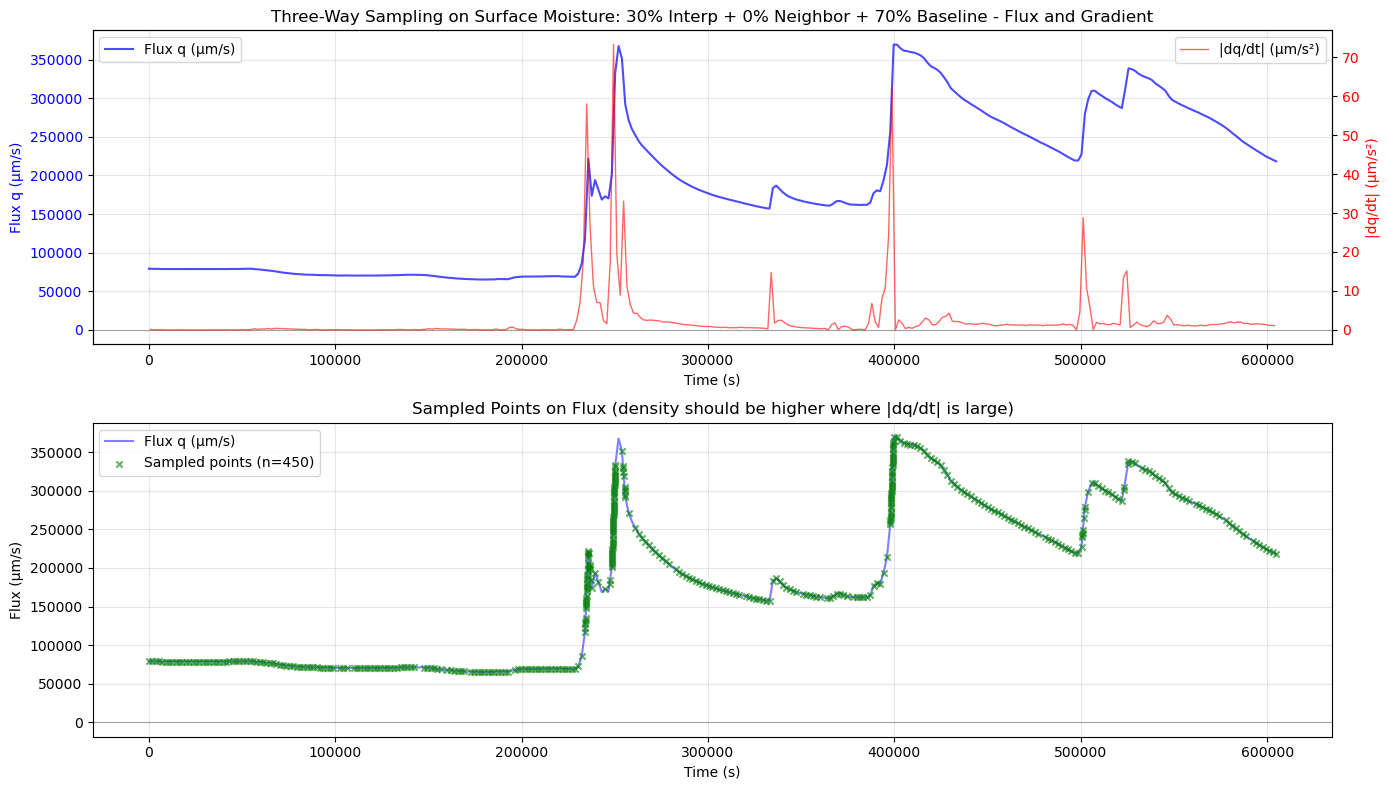


VISUALIZATION 2: Uniform vs Gradient-Based Comparison


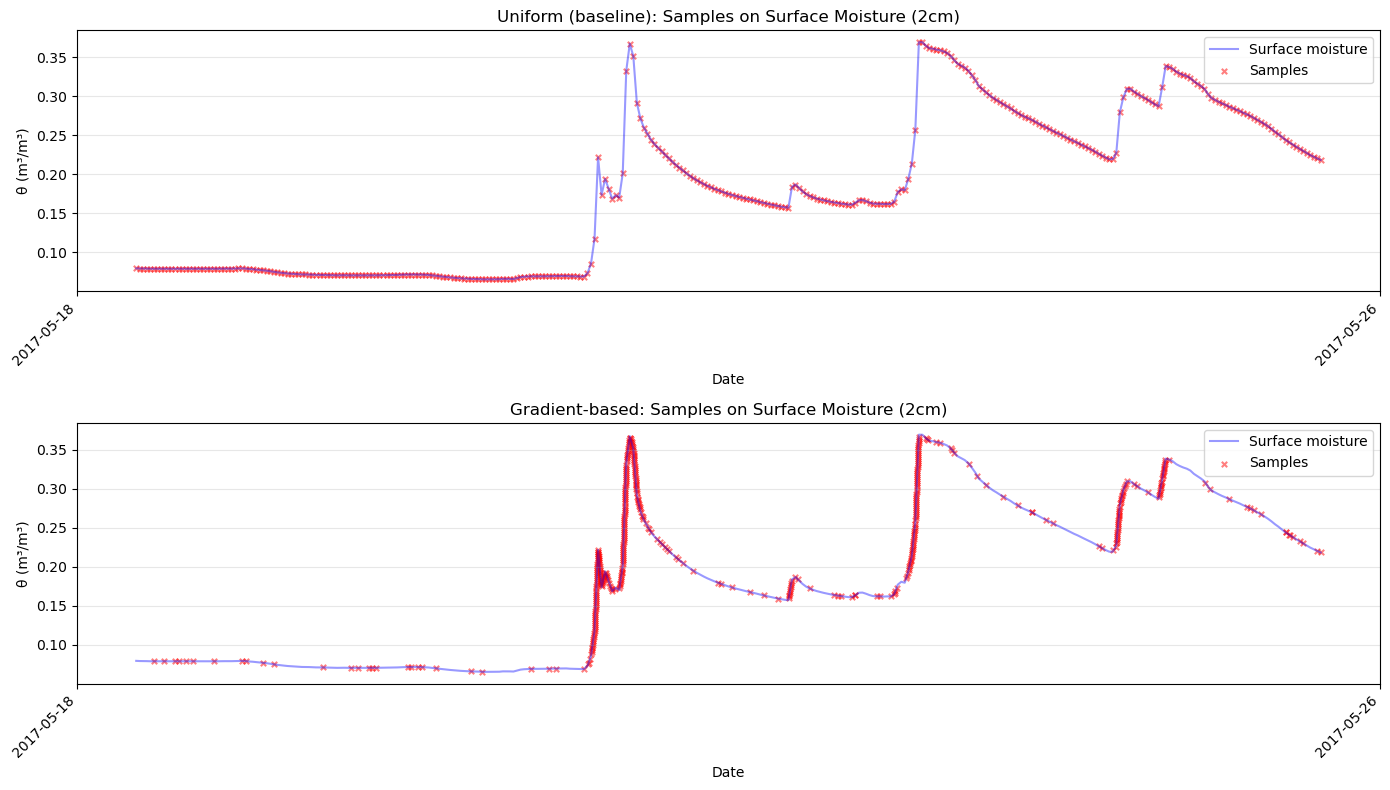


QUANTITATIVE VERIFICATION
Configuration: 30% interp + 0% neighbor + 70% baseline

Gradient Enrichment:
  Average |dθ/dt| at sampled points:  1.284e-05 m³/m³/s
  Average |dθ/dt| overall:            2.309e-06 m³/m³/s
  Enrichment factor:                  5.56x

Sample Composition:
  Interpolated points:  135
  Neighbor points:      0
  Baseline points:      315

Expected: Enrichment > 1.5x (samples concentrated in high-gradient regions)
  → Regions with rapid moisture changes (drying/wetting events)


In [245]:
# ============================================================================
# TEST THREE-WAY GRADIENT-BASED SAMPLING ON SURFACE MOISTURE DATA
# ============================================================================

from src.gradient_based_sampling import (
    gradient_based_sampling,
    visualize_gradient_sampling,
    compare_sampling_methods,
    compute_gradient_weights
)

# Prepare surface moisture data for sampling
theta_surface = theta_2cm.copy()
times_surface = times_seconds.copy()

# Remove NaN values for gradient-based sampling
valid_mask = ~pd.isna(theta_surface)
theta_clean = theta_surface[valid_mask]
times_clean = times_surface[valid_mask]
datetime_clean = datetime_col[valid_mask]

# Convert to tensors - ensure numeric type
theta0_times_t = torch.tensor(np.array(times_clean, dtype=np.float32), dtype=torch.float32).to(device)
theta0_values = torch.tensor(np.array(theta_clean, dtype=np.float32), dtype=torch.float32).to(device)

print("\n" + "="*70)
print("THREE-WAY GRADIENT-BASED SAMPLING TEST - SURFACE MOISTURE")
print("="*70)

# Compute gradient weights
gradient_weights, gradients = compute_gradient_weights(theta0_times_t, theta0_values, device)

print(f"\nGradient Statistics:")
print(f"  Max |dθ/dt|:  {gradients.abs().max().item():.3e} m³/m³/s")
print(f"  Mean |dθ/dt|: {gradients.abs().mean().item():.3e} m³/m³/s")
print(f"  Min |dθ/dt|:  {gradients.abs().min().item():.3e} m³/m³/s")

# Find high-gradient regions
high_grad_threshold = gradients.abs().quantile(0.7)  # Top 30%
high_grad_mask = gradients.abs() > high_grad_threshold
print(f"\nHigh-gradient points (top 30%): {high_grad_mask.sum().item()}")

# Test parameters - THREE-WAY SAMPLING
batch_size_bc = 450
interp_ratio = 0.30      # 80% from gradient-interpolated points
neighbor_ratio = 0.00    # 5% from neighbors of high-gradient regions
baseline_ratio = 0.7    # 15% from uniform baseline
neighbor_expansion = 0   # ±2 neighbors around high gradients
power = 2.0              # >1 emphasizes high gradients more aggressively
gradient_threshold = 0.7

# Generate three-way gradient-based samples
t_bc_gradient, sample_info = gradient_based_sampling(
    theta0_times_t,
    theta0_values,
    batch_size_bc,
    device=device,
    use_interpolation=True,
    interp_ratio=interp_ratio,
    neighbor_ratio=neighbor_ratio,
    baseline_ratio=baseline_ratio,
    neighbor_expansion=neighbor_expansion,
    gradient_threshold=gradient_threshold,
    power=power
)

print(f"\nGenerated {len(t_bc_gradient)} gradient-weighted samples")
print(f"Sample range: [{t_bc_gradient.min():.1f}, {t_bc_gradient.max():.1f}] s")
print(f"\nSample Breakdown:")
print(f"  Interpolated:  {sample_info['n_interp_samples']} ({sample_info['actual_ratios']['interp']*100:.1f}%)")
print(f"  Neighbors:     {sample_info['n_neighbor_samples']} ({sample_info['actual_ratios']['neighbor']*100:.1f}%)")
print(f"  Baseline:      {sample_info['n_baseline_samples']} ({sample_info['actual_ratios']['baseline']*100:.1f}%)")

# Visualize gradient-based sampling
print("\n" + "="*70)
print("VISUALIZATION 1: Three-Way Gradient Sampling Details")
print("="*70)
visualize_gradient_sampling(
    theta0_times_t,
    theta0_values,
    t_bc_gradient,
    sample_info,
    title=f'Three-Way Sampling on Surface Moisture: {interp_ratio*100:.0f}% Interp + {neighbor_ratio*100:.0f}% Neighbor + {baseline_ratio*100:.0f}% Baseline'
)
plt.show()

# Compare uniform vs gradient-based sampling
print("\n" + "="*70)
print("VISUALIZATION 2: Uniform vs Gradient-Based Comparison")
print("="*70)

configs = [
    {"name": "Uniform (baseline)", "interp": 0.0, "neighbor": 0.0, "baseline": 1.0},
    {"name": "Gradient-based", "interp": 0.80, "neighbor": 0.05, "baseline": 0.15},
]

fig, axes = plt.subplots(len(configs), 1, figsize=(14, 4*len(configs)))
if len(configs) == 1:
    axes = [axes]

for i, config in enumerate(configs):
    # Generate samples
    if config['interp'] == 0.0:
        # Pure uniform
        uniform_idx = torch.randperm(len(theta0_times_t), device=device)[:batch_size_bc]
        t_bc_test = theta0_times_t[uniform_idx]
    else:
        t_bc_test, info_test = gradient_based_sampling(
            theta0_times_t, theta0_values, batch_size_bc, device=device,
            use_interpolation=(config['interp'] > 0),
            interp_ratio=config['interp'],
            neighbor_ratio=config['neighbor'],
            baseline_ratio=config['baseline'],
            neighbor_expansion=2,
            gradient_threshold=0.7,
            power=power
        )

    samples_np = t_bc_test.detach().cpu().numpy().flatten()
    times_np = theta0_times_t.cpu().numpy().flatten()
    values_np = theta0_values.cpu().numpy().flatten()

    # Convert times to datetime for plotting
    datetime_samples = datetime_clean.iloc[0] + pd.to_timedelta(samples_np, unit='s')
    
    # Scatter on moisture
    ax = axes[i]
    ax.plot(datetime_clean, values_np, 'b-', linewidth=1.5, alpha=0.4, label='Surface moisture')
    ax.scatter(datetime_samples, np.interp(samples_np, times_np, values_np),
            s=15, c='red', alpha=0.5, marker='x', label='Samples')
    ax.set_ylabel('θ (m³/m³)')
    ax.set_xlabel('Date')
    ax.set_title(f"{config['name']}: Samples on Surface Moisture (2cm)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Quantitative verification
print("\n" + "="*70)
print("QUANTITATIVE VERIFICATION")
print("="*70)

# Check if samples are concentrated in high-gradient regions
samples_np = t_bc_gradient.detach().cpu().numpy().flatten()
times_np = theta0_times_t.cpu().numpy().flatten()

# For each sample, find nearest data point and check its gradient
sample_gradients = []
for s in samples_np:
    idx = torch.argmin(torch.abs(theta0_times_t.flatten() - s))
    if idx < len(gradients):
        sample_gradients.append(gradients[idx].abs().item())

sample_grad_mean = np.mean(sample_gradients)
overall_grad_mean = gradients.abs().mean().item()

print(f"Configuration: {interp_ratio*100:.0f}% interp + {neighbor_ratio*100:.0f}% neighbor + {baseline_ratio*100:.0f}% baseline")
print(f"\nGradient Enrichment:")
print(f"  Average |dθ/dt| at sampled points:  {sample_grad_mean:.3e} m³/m³/s")
print(f"  Average |dθ/dt| overall:            {overall_grad_mean:.3e} m³/m³/s")
print(f"  Enrichment factor:                  {sample_grad_mean/overall_grad_mean:.2f}x")
print(f"\nSample Composition:")
print(f"  Interpolated points:  {sample_info['n_interp_samples']}")
print(f"  Neighbor points:      {sample_info['n_neighbor_samples']}")
print(f"  Baseline points:      {sample_info['n_baseline_samples']}")
print("\nExpected: Enrichment > 1.5x (samples concentrated in high-gradient regions)")
print("  → Regions with rapid moisture changes (drying/wetting events)")
print("="*70)

TRAINING WITH MOISTURE BC (Dirichlet)
  Surface BC: θ(z=0, t) = θ₀(t)
  Data points: 337
  Duration: 7.0 days
  Moisture range: 0.0652 - 0.3694 m³/m³
  Soil: θr=0.010, θs=0.400

Updated soil_params: {'theta_s': 0.4, 'theta_r': 0.01, 'alpha': 3.4, 'n': 1.7, 'Ks': 1e-05, 'l': 0.5}

NORMALIZATION SCALES
Length scale (L):           1.000 m
Head scale (H_*):           1.000 m
Conductivity scale (K_*):   1.00e-05 m/s
Flux scale (Q_*):           1.00e-05 m/s
Water content span (θ_*):   0.390
Time scale (T):             3.90e+04 s (10.83 hours)
Dimensionless α̃:            3.4000
Dimensionless S̃_max:        0.0000



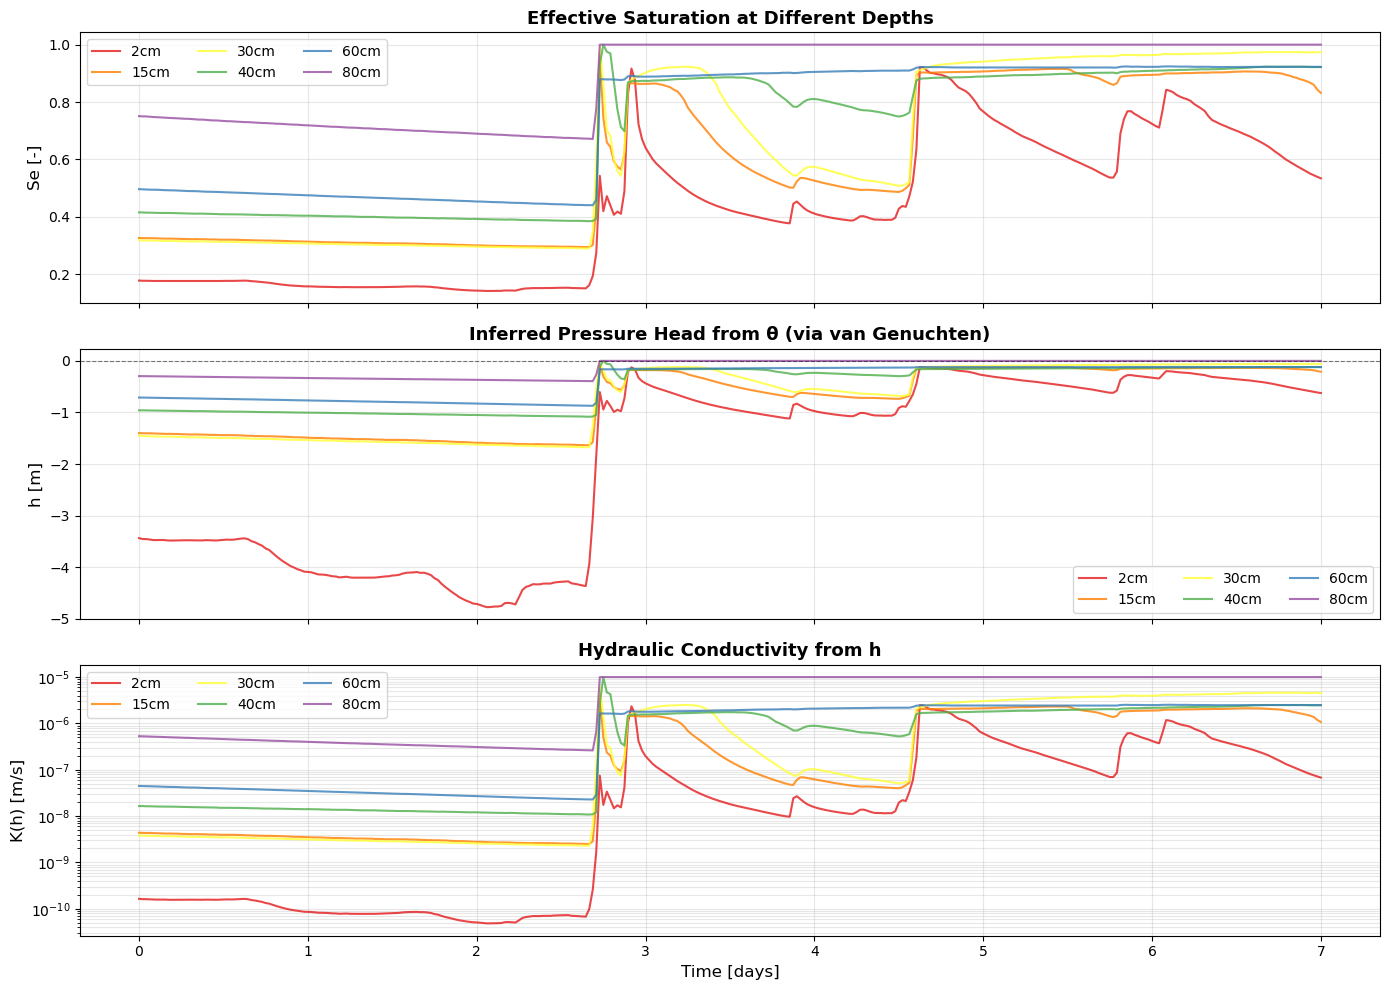


STATISTICS BY DEPTH

2cm:
  Se range:    0.1416 - 0.9214
  h range:     -4.7741 - -0.1207 m
  K range:     4.833e-11 - 2.459e-06 m/s
  Data points: 337

15cm:
  Se range:    0.2946 - 0.9671
  h range:     -1.6341 - -0.0688 m
  K range:     2.508e-09 - 4.158e-06 m/s
  Data points: 337

30cm:
  Se range:    0.2898 - 0.9909
  h range:     -1.6749 - -0.0316 m
  K range:     2.294e-09 - 6.249e-06 m/s
  Data points: 337

40cm:
  Se range:    0.3847 - 1.0000
  h range:     -1.0832 - 0.0000 m
  K range:     1.079e-08 - 1.000e-05 m/s
  Data points: 337

60cm:
  Se range:    0.4406 - 0.9242
  h range:     -0.8700 - -0.1178 m
  K range:     2.287e-08 - 2.530e-06 m/s
  Data points: 337

80cm:
  Se range:    0.6712 - 1.0000
  h range:     -0.3925 - 0.0000 m
  K range:     2.611e-07 - 1.000e-05 m/s
  Data points: 337


In [246]:
# Time series of Se_obs, h inferred from Se, and K(h) from CCZO theta data at ALL DEPTHS
import numpy as np
import torch
import matplotlib.pyplot as plt
# ============================================================================
# PREPARE MOISTURE BC DATA
# ============================================================================

# Prepare theta0_data tuple for training (times, moisture values)
# Remove NaN values from surface moisture data
valid_mask = ~pd.isna(theta_2cm)
theta0_times = times_seconds[valid_mask]
theta0_values = theta_2cm[valid_mask]

# Convert to numpy arrays to ensure proper type
theta0_times = np.array(theta0_times, dtype=np.float64)
theta0_values = np.array(theta0_values, dtype=np.float64)

theta0_data = (theta0_times, theta0_values)

print("="*70)
print("TRAINING WITH MOISTURE BC (Dirichlet)")
print("  Surface BC: θ(z=0, t) = θ₀(t)")
print(f"  Data points: {len(theta0_data[0])}")
print(f"  Duration: {theta0_data[0][-1]/86400:.1f} days")
print(f"  Moisture range: {min(theta0_data[1]):.4f} - {max(theta0_data[1]):.4f} m³/m³")
print(f"  Soil: θr={soil_params['theta_r']:.3f}, θs={soil_params['theta_s']:.3f}")
print("="*70 + "\n")


from src.normalization_helper import NormalizationHelper
# Override soil parameters here to test and re-run downstream plots
# Edit values below and run this cell, then re-run the time-series cell.
soil_params = {
    'theta_s': 0.40,   # saturated water content [-]
    'theta_r': 0.01,   # residual water content [-]
    'alpha':3.4,    # 1/m (van Genuchten α)
    'n': 1.7,         # van Genuchten n (>1)
    'Ks': 1.0e-5,      # m/s (saturated conductivity)
    'l': 0.50,         # Mualem pore-connectivity parameter
}
print("Updated soil_params:", soil_params)

# Initialize normalization helper (choose same L, S_max used in training)
L = 1.0
S_max = 0.0
normalizer = NormalizationHelper(soil_params, L=L, S_max=S_max)

# ============================================================================
# PROCESS ALL DEPTH LEVELS
# ============================================================================

# Collect theta data from all depths
theta_depths = {
    '2cm': theta_2cm,
    '15cm': theta_15cm,
    '30cm': theta_30cm,
    '40cm': theta_40cm,
    '60cm': theta_60cm,
    '80cm': theta_80cm,
}

# Colors for different depths
colors = ['#e41a1c', '#ff7f00', '#ffff33', '#4daf4a', '#377eb8', '#984ea3']
depth_names = ['2cm', '15cm', '30cm', '40cm', '60cm', '80cm']

# Storage for all depths
all_results = {}

for depth_name in depth_names:
    theta_vals = theta_depths[depth_name]
    
    # Get valid data
    valid_mask = ~pd.isna(theta_vals)
    times_sec = times_seconds[valid_mask]
    theta_clean = theta_vals[valid_mask]
    
    # Convert to numpy
    times_sec = np.array(times_sec, dtype=np.float64)
    theta_clean = np.array(theta_clean, dtype=np.float64)
    
    if len(theta_clean) == 0:
        print(f"Warning: No valid data for {depth_name}")
        continue
    
    # Compute Se_obs = (theta - theta_r) / (theta_s - theta_r)
    theta_r = normalizer.theta_r
    theta_star = normalizer.theta_star
    Se_obs = np.clip((theta_clean - theta_r) / theta_star, 1e-6, 1.0 - 1e-6)
    
    # Invert van Genuchten to estimate h (unsaturated: h < 0). For Se≈1, set h = 0.
    alpha_tilde = normalizer.alpha_tilde
    n_vg = normalizer.n
    m_vg = normalizer.m
    
    Se_t = torch.tensor(Se_obs, dtype=torch.float32).view(-1, 1)
    with torch.no_grad():
        # h_tilde = - ((Se^{-1/m} - 1)^{1/n}) / alpha_tilde, for Se in (0,1)
        inv_term = torch.pow(torch.clamp(Se_t, 1e-6, 1.0 - 1e-6), -1.0 / m_vg) - 1.0
        h_tilde_unsat = - torch.pow(torch.clamp(inv_term, min=0.0), 1.0 / n_vg) / float(alpha_tilde)
        # If Se very close to 1 (>= 1 - eps), assume saturated at h = 0
        eps = 1e-6
        sat_mask = (Se_t >= 1.0 - eps)
        h_tilde = torch.where(sat_mask, torch.zeros_like(h_tilde_unsat), h_tilde_unsat)
        
        # Convert to dimensional head h [m]
        h_dim = normalizer.denormalize_h(h_tilde)
        
        # Compute K_tilde(h) and dimensional K(h)
        K_rel = normalizer.K_tilde(h_tilde)
        Ks = soil_params['Ks']
        K_dim = K_rel * Ks
    
    h_series = h_dim.cpu().numpy().flatten()
    K_series = K_dim.cpu().numpy().flatten()
    t_days = times_sec / 86400.0
    
    all_results[depth_name] = {
        't_days': t_days,
        'Se': Se_obs,
        'h': h_series,
        'K': K_series,
    }

# ============================================================================
# PLOT ALL DEPTHS
# ============================================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Plot 1: Se for all depths
for i, depth_name in enumerate(depth_names):
    if depth_name in all_results:
        data = all_results[depth_name]
        axes[0].plot(data['t_days'], data['Se'], color=colors[i], 
                    label=depth_name, linewidth=1.5, alpha=0.8)
axes[0].set_ylabel('Se [-]', fontsize=12)
axes[0].set_title('Effective Saturation at Different Depths', fontsize=13, fontweight='bold')
axes[0].legend(ncol=3, fontsize=10, loc='best')
axes[0].grid(True, alpha=0.3)

# Plot 2: h for all depths
for i, depth_name in enumerate(depth_names):
    if depth_name in all_results:
        data = all_results[depth_name]
        axes[1].plot(data['t_days'], data['h'], color=colors[i], 
                    label=depth_name, linewidth=1.5, alpha=0.8)
axes[1].set_ylabel('h [m]', fontsize=12)
axes[1].set_title('Inferred Pressure Head from θ (via van Genuchten)', fontsize=13, fontweight='bold')
axes[1].axhline(0.0, color='k', linewidth=0.8, alpha=0.5, linestyle='--')
axes[1].legend(ncol=3, fontsize=10, loc='best')
axes[1].grid(True, alpha=0.3)

# Plot 3: K for all depths
for i, depth_name in enumerate(depth_names):
    if depth_name in all_results:
        data = all_results[depth_name]
        axes[2].semilogy(data['t_days'], np.maximum(data['K'], 1e-12), 
                        color=colors[i], label=depth_name, linewidth=1.5, alpha=0.8)
axes[2].set_ylabel('K(h) [m/s]', fontsize=12)
axes[2].set_title('Hydraulic Conductivity from h', fontsize=13, fontweight='bold')
axes[2].legend(ncol=3, fontsize=10, loc='best')
axes[2].grid(True, which='both', alpha=0.3)
axes[2].set_xlabel('Time [days]', fontsize=12)

plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "="*70)
print("STATISTICS BY DEPTH")
print("="*70)
for depth_name in depth_names:
    if depth_name in all_results:
        data = all_results[depth_name]
        print(f"\n{depth_name}:")
        print(f"  Se range:    {data['Se'].min():.4f} - {data['Se'].max():.4f}")
        print(f"  h range:     {data['h'].min():.4f} - {data['h'].max():.4f} m")
        print(f"  K range:     {data['K'].min():.3e} - {data['K'].max():.3e} m/s")
        print(f"  Data points: {len(data['t_days'])}")
print("="*70)

In [247]:
# ============================================================================
# PREPARE INITIAL CONDITION FROM MEASURED THETA PROFILE
# ============================================================================

# Extract initial theta values from all depths at t=0
ic_depths = []
ic_theta = []

depth_mapping = {
    '2cm': (0.02, theta_2cm),
    '15cm': (0.15, theta_15cm),
    '30cm': (0.30, theta_30cm),
    '40cm': (0.40, theta_40cm),
    '60cm': (0.60, theta_60cm),
    '80cm': (0.80, theta_80cm),
}

print("="*70)
print("CREATING INITIAL CONDITION FROM MEASURED THETA PROFILE")
print("="*70)

for depth_name, (depth_m, theta_series) in depth_mapping.items():
    # Get first valid (non-NaN) value
    valid_mask = ~pd.isna(theta_series)
    if valid_mask.any():
        # Handle both pandas Series and numpy arrays
        if isinstance(theta_series, pd.Series):
            theta_ic = theta_series[valid_mask].iloc[0]
        else:
            theta_ic = theta_series[valid_mask][0]
        ic_depths.append(depth_m)
        ic_theta.append(theta_ic)
        print(f"  {depth_name:6s}: θ = {theta_ic:.4f} m³/m³")

ic_profile = {
    'depths': ic_depths,  # meters below surface
    'theta': ic_theta     # volumetric water content
}

print(f"\nIC Profile has {len(ic_depths)} measurement points")
print("="*70 + "\n")

# ============================================================================
# TRAINING CONFIGURATION - MOISTURE BC WITH MEASURED IC
# ============================================================================

# Define network configurations
h_net_config = {'hidden_dim': 64, 'num_layers': 4}
zb_net_config = {'hidden_dim': 32, 'num_layers': 3}

# ============================================================================
# CHOOSE INITIAL CONDITION TYPE
# ============================================================================
# Options:
#   'obs'        - Use measured profile with linear extrapolation to water table
#   'linear'     - Simple linear from surface h_obs to water table h=0
#   'hydrostatic' - Hydrostatic profile (h = -zb - z)
ic_type = 'hydrostatic'  # ← Change this to switch IC types

print(f"Using IC type: {ic_type}")
print("="*70 + "\n")

# ============================================================================
# TRAIN PINN WITH MOISTURE BC AND MEASURED IC PROFILE
# ============================================================================

print("Starting PINN Training with Moisture BC and Measured IC")
print("="*70)

# Gradient-based sampling parameters
batch_size_bc = 250
interp_ratio = 0.80
neighbor_ratio = 0.05
baseline_ratio = 0.15
neighbor_expansion = 2
gradient_threshold = 0.7
power = 2.0

# Train with pool + batch approach using gradient-based boundary sampling
model_pool, losses_pool, comps_pool, sample_losses, sample_comps, sample_epochs = train_pinn_pool_batch_autoweight(
    soil_params=soil_params,
    theta0_data=theta0_data,  # Moisture BC data - REQUIRED
    Sy=0.3,
    zr=0.5,
    h_net_config=h_net_config,
    zb_net_config=zb_net_config,
    L=4.0,
    S_max=1e-7,
    n_epochs=100000,
    learning_rate=5e-4,
    zb_initial=6.1,
    weight_update_freq=1e10,
    weight_lr=0.1,
    use_initial_scales=True,
    
    # Pool + batch parameters
    cache_size=10000,
    batch_size=500,
    resample_freq=100,
    boundary_ratio=0.7,
    high_residual_ratio=0.6,
    temperature=0.3,
    
    # Gradient-based boundary sampling parameters
    batch_size_bc=batch_size_bc,
    interp_ratio=interp_ratio,
    neighbor_ratio=neighbor_ratio,
    baseline_ratio=baseline_ratio,
    gradient_neighbor_expansion=neighbor_expansion,
    gradient_threshold=gradient_threshold,
    gradient_power=power,
    
    # Measured initial condition profile
    ic_profile=ic_profile,  # ← Measured theta profile
    ic_type=ic_type,        # ← IC type: 'obs', 'linear', or 'hydrostatic'
    
    # Device and checkpointing
    device=device,
    checkpoint_dir='checkpoints_train',
    checkpoint_freq=5000,
)

print("\n" + "="*70)
print("Training Complete!")
print("="*70)

CREATING INITIAL CONDITION FROM MEASURED THETA PROFILE
  2cm   : θ = 0.0794 m³/m³
  15cm  : θ = 0.1372 m³/m³
  30cm  : θ = 0.1342 m³/m³
  40cm  : θ = 0.1720 m³/m³
  60cm  : θ = 0.2036 m³/m³
  80cm  : θ = 0.3028 m³/m³

IC Profile has 6 measurement points

Using IC type: hydrostatic

Starting PINN Training with Moisture BC and Measured IC

NORMALIZATION SCALES
Length scale (L):           4.000 m
Head scale (H_*):           4.000 m
Conductivity scale (K_*):   1.00e-05 m/s
Flux scale (Q_*):           1.00e-05 m/s
Water content span (θ_*):   0.390
Time scale (T):             1.56e+05 s (43.33 hours)
Dimensionless α̃:            13.6000
Dimensionless S̃_max:        0.0400

Fixed weights mode enabled (weight_update_freq=10000000000.0 >= n_epochs=100000)
Checkpointing enabled: saving every 5000 epochs to checkpoints_train/
Training for 100000 epochs | lr=0.0005
Device: cpu | GPUs available: 0
Adaptive weighting: updating every 10000000000.0 epochs
Pool + Batch: cache_size=10000, batch_size=500

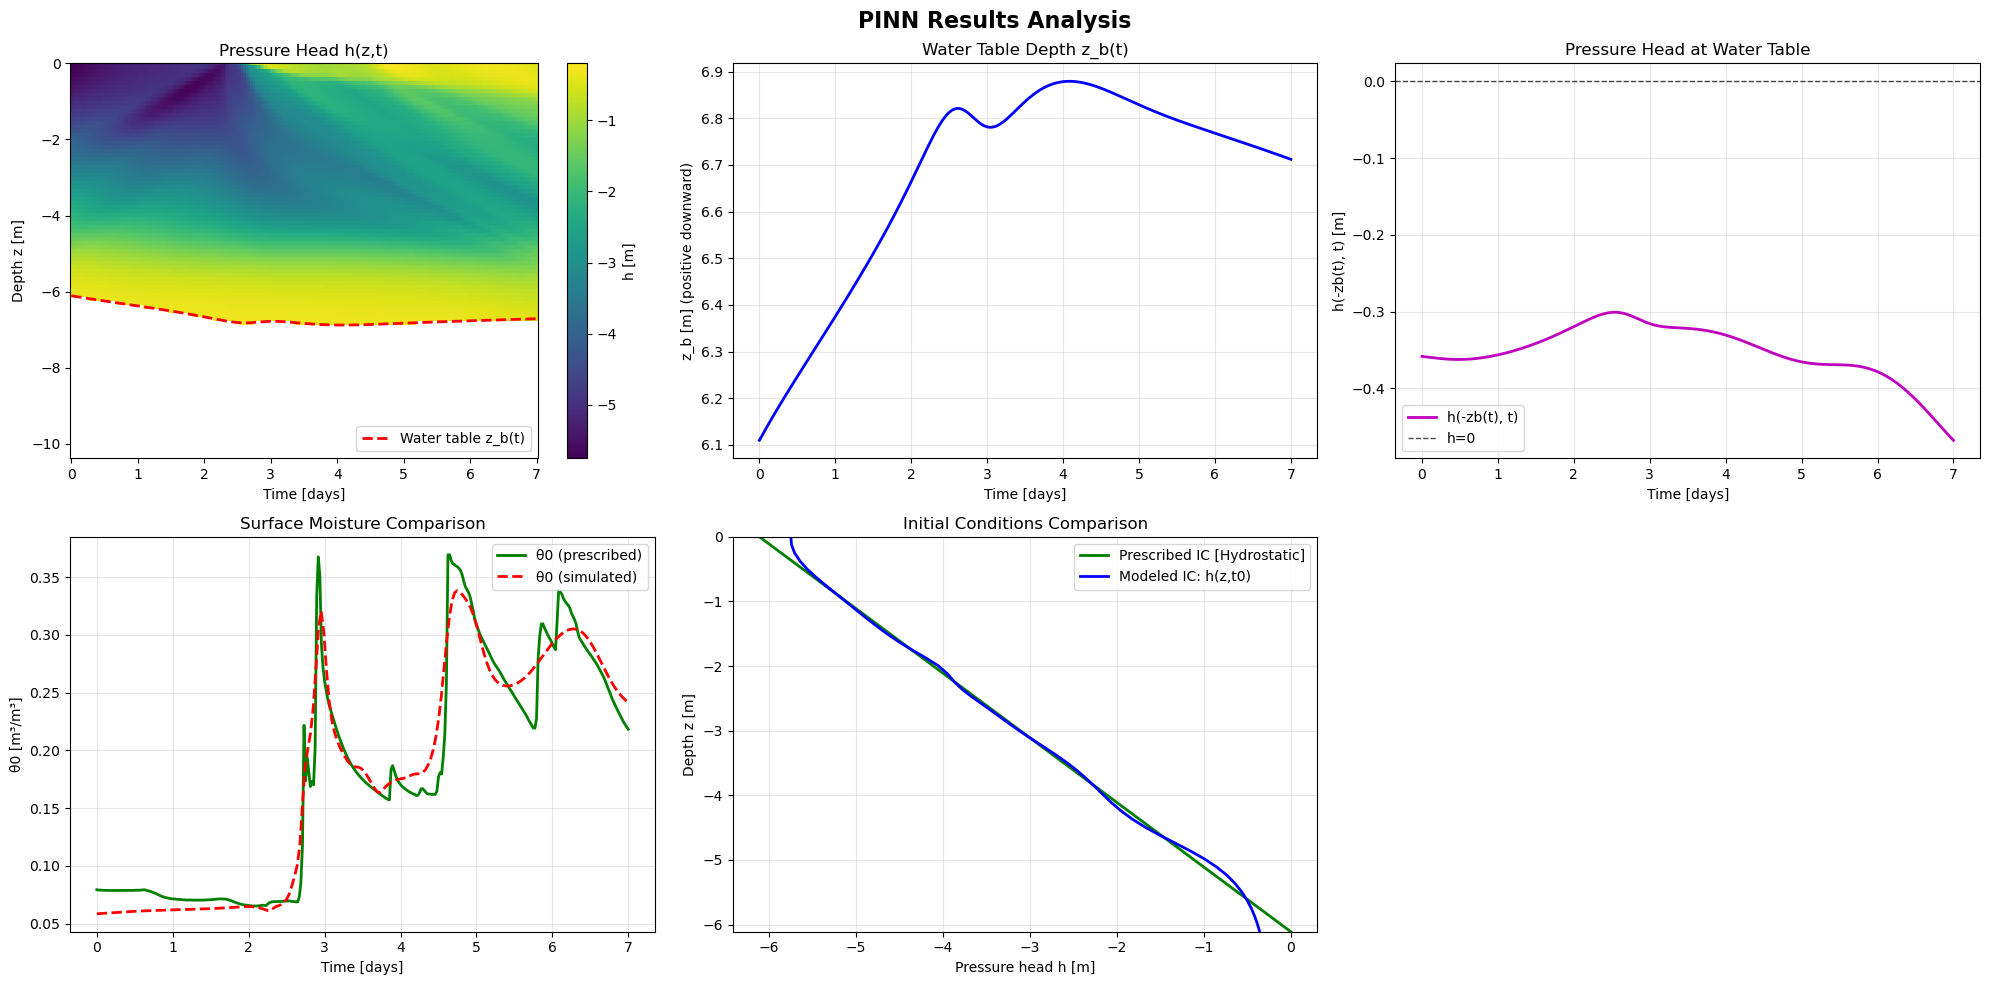


Summary Statistics:
Water table depth range: 6.110 to 6.879 m
Surface head range: -5.748 to -0.200 m
h(-zb(t), t) range: -0.467583 to -0.300851 m
Max |h(-zb(t), t)|: 0.467583 m (should be close to 0)
Max IC error: 0.361834 m


In [248]:
# Import visualization functions from external module
from src.visualization import plot_comprehensive_results

# Use theta0_data for moisture BC visualization
plot_comprehensive_results(model_pool, theta0_data, soil_params, device=device)

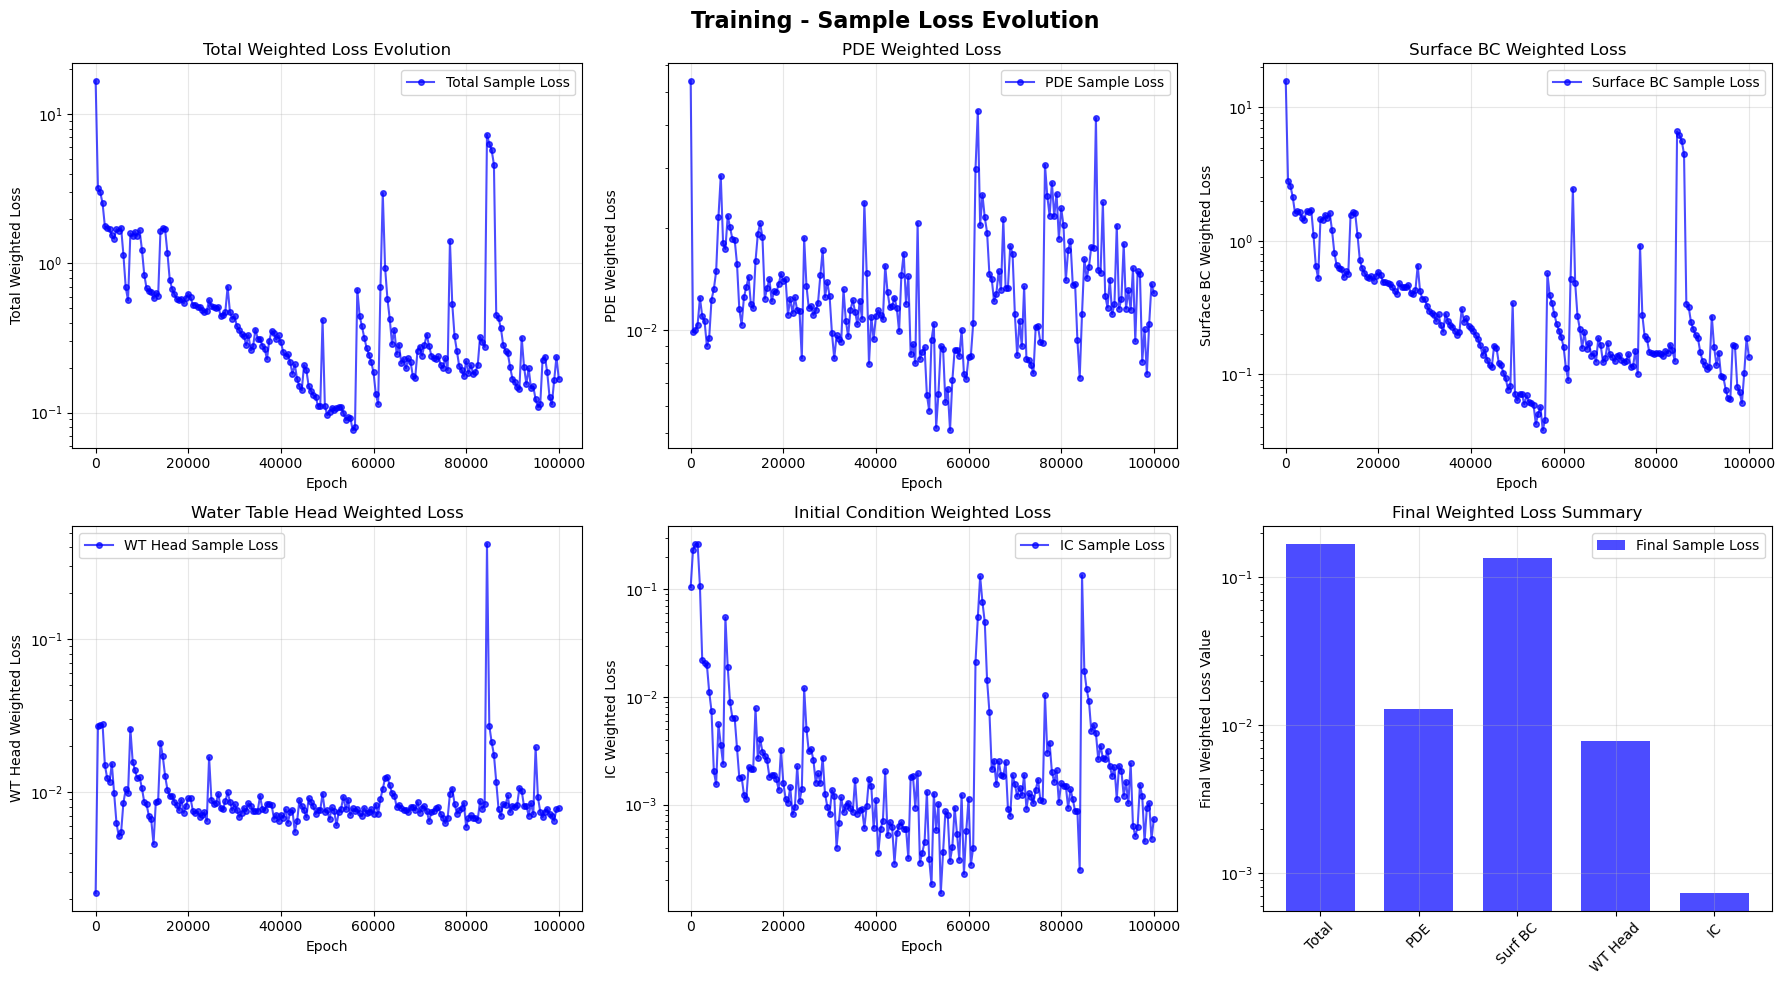

In [249]:
# Import and use the loss plotting function from external module
from src.visualization import plot_training_losses

# Plot the sample losses (computed over full dataset every 500 epochs)
# This gives a smoother, less noisy view of the loss evolution
plot_training_losses(losses_pool, comps_pool, sample_losses, sample_comps, sample_epochs)